Author: Daniel Abadjiev   
Date: Sep 3, 2025   
Description: Try to make/test a model that uses the ASIC architecture, borrowing from danielTestNotebook.ipynb   

In [2]:
from OptimizedDataGenerator4 import *
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

noGPU=False
if noGPU:
    tf.config.set_visible_devices([], 'GPU')

print(tf.config.experimental.list_physical_devices())
print(tf.test.is_built_with_cuda())
print(tf.test.is_built_with_gpu_support())
print(tf.test.is_gpu_available())

2025-09-04 11:12:15.725273: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-04 11:12:15.760691: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-04 11:12:16.224396: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-04 11:12:16.225898: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-04 11:12:17.178507: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


2025-09-04 11:12:19.266880: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-09-04 11:12:19.266909: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: kdplab01
2025-09-04 11:12:19.266915: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: kdplab01
2025-09-04 11:12:19.266972: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 570.153.2
2025-09-04 11:12:19.266986: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.65.06  Release Build  (root@kdplab01)  Tue Aug 12 08:34:56 AM CDT 2025
GCC version:  gcc ver

In [ ]:
#// plotting code from google ai https://www.google.com/search?client=firefox-b-1-d&q=plot+tensorflow+model+history
# then modified
def plotModelHistory(history,modelNum = -999):
    plt.subplot(211)
    # Plot training & validation loss values
    plt.plot(history.history['loss'],label="Train")
    plt.plot(history.history['val_loss'],label="Validation")
    plt.title(f'Model {modelNum} loss and accuracy')
    plt.ylabel('Loss')
    # plt.xlabel('Epoch')
    plt.legend()
    plt.subplot(212)
    # Plot training & validation accuracy values
    plt.plot(history.history['binary_accuracy'],label="Train")
    plt.plot(history.history['val_binary_accuracy'],label="Validation")
    # plt.title(f'Model {modelNum} accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.show()

# validation_dir = "./tf_records1000Daniel/tfrecords_validation/"
# train_dir = "./tf_records1000Daniel/tfrecords_train/"
# validation_dir = "/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData/filtering_records512_data_shuffled_single_bigData/tfrecords_validation/"
# train_dir = "/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData/filtering_records512_data_shuffled_single_bigData/tfrecords_train/"                  
batch_size = 2048;
validation_dir = f"/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData_try2/filtering_records{batch_size}_data_shuffled_single_bigData/tfrecords_validation/"
train_dir = f"/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData_try2/filtering_records{batch_size}_data_shuffled_single_bigData/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster','y_local']
trainODG = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description)
validationODG = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description)
# trainODG._parse_tfrecord_fn()

In [14]:
#Make a model that has multpile layers
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="y_local")
input3 = tf.keras.layers.Input(shape=(1,), name="x_size")
# input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
inputList = [input1, input2,input3,input4]
inputs = tf.keras.layers.Concatenate()(inputList)
stack = tf.keras.layers.Dense(58,activation='relu')(inputs)
# stack = tf.keras.layers.Dense(10)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model1 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
# callbacks=[]
# learningRates = [0.1,0.9,0.6,0.3,0.1,0.03,0.01,0.001,0.0001,0.00001,0.000001]
# callbacks.append(tf.keras.callbacks.LearningRateScheduler(lambda epoch,lr : lr if epoch<5 else lr*np.exp(-0.1)))
callbacks=[]
history1 = model1.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=10)

Epoch 1/50
2506/2506 [==============================] - 137s 55ms/step - loss: 0.2882 - binary_accuracy: 0.8534 - val_loss: 0.2459 - val_binary_accuracy: 0.8735
Epoch 2/50
2506/2506 [==============================] - 137s 55ms/step - loss: 0.2389 - binary_accuracy: 0.8777 - val_loss: 0.2348 - val_binary_accuracy: 0.8806
Epoch 3/50
2506/2506 [==============================] - 136s 54ms/step - loss: 0.2318 - binary_accuracy: 0.8813 - val_loss: 0.2285 - val_binary_accuracy: 0.8828
Epoch 4/50
2506/2506 [==============================] - 136s 54ms/step - loss: 0.2240 - binary_accuracy: 0.8844 - val_loss: 0.2201 - val_binary_accuracy: 0.8876
Epoch 5/50
2506/2506 [==============================] - 138s 55ms/step - loss: 0.2173 - binary_accuracy: 0.8886 - val_loss: 0.2148 - val_binary_accuracy: 0.8900
Epoch 6/50
2506/2506 [==============================] - 136s 54ms/step - loss: 0.2127 - binary_accuracy: 0.8911 - val_loss: 0.2116 - val_binary_accuracy: 0.8911
Epoch 7/50
2506/2506 [============

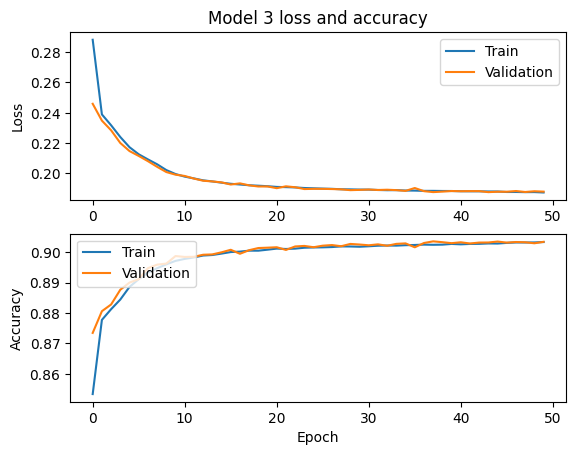

627/627 [==============================] - 28s 45ms/step - loss: 0.1880 - binary_accuracy: 0.9034
model1 validation test accuracy: 0.9033747315406799
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 z_global (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 y_local (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 x_size (InputLayer)         [(None, 1)]                  0         []                            
                                                                                                  
 y_profile (InputLayer)      [(None, 13)]

In [15]:
plotModelHistory(history1,3)
test_loss, test_acc = model1.evaluate(validationODG)
print("model1 validation test accuracy: "+str(test_acc))
model1.summary()

In [16]:
saveModels = True;
if saveModels:
    filepath = "./DanielModels/ASIC50EpochsFullDatasetBatch1024.keras"
    model1.save(filepath)